In [1]:
# 2D histogrammer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import os

mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
# 2D crystal layout from mapdf
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]

mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)



ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)

ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)

scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))

for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i

for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072


In [2]:
# Load data
#highintppbounds = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter_ppbounds.txt')
#lowintppbounds = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/mcenter_ppbounds.txt')

#highinteventcounts = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/hcentereventrates.txt')
#lowinteventcounts = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/mcentereventrates.txt')

#highintoffsets = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/tsvsh/time_offset_calibrationit10.tsv', delimiter = '\t')[:, 4]
#lowintoffsets = np.loadtxt('/home/kale-chen/Documents/PET/MDA_03162026/Data/tsvs/time_offset_calibrationit10.tsv', delimiter = '\t')[:, 4]
#offsets = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/CalibrationDataPreparer/tsvs/time_offset_calibrationit10.tsv', delimiter = '\t')[:, 4]

#eventc = np.loadtxt('/home/kale-chen/Documents/PET/MDA_04112026/test.txt')

#peak_times = np.loadtxt('/home/kale-chen/Documents/PET/Sensitivity Normalization/peaksm.txt')

#countsh = np.loadtxt('/home/kale-chen/Documents/PET/Sensitivity Normalization/eventcountsh.txt')
#countshrel = countsh / np.median(countsh)
#countsm = np.loadtxt('/home/kale-chen/Documents/PET/Sensitivity Normalization/eventcountsm.txt')
#countsmrel = countsm / np.median(countsm)
#countsmnorm = np.loadtxt('/home/kale-chen/Documents/PET/Sensitivity Normalization/eventcountsmnorm.txt')
#countsmnormrel = countsmnorm / np.median(countsmnorm)
#meansnocal = np.fromfile('/home/kale-chen/Documents/PET/TimeCalibration/CalibrationDataPreparer/means_nocal.bin', dtype = np.float32)
#meanscal = np.fromfile('/home/kale-chen/Documents/PET/TimeCalibration/CalibrationDataPreparer/means_cal.bin', dtype = np.float32)
normfactorsL = np.fromfile('/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/it19L.bin', dtype = np.float32)
normfactorsR = np.fromfile('/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/it19R.bin', dtype = np.float32)
normfactors = np.concatenate((normfactorsL, normfactorsR), axis = 0)

In [6]:
heatmapRlow = np.zeros((32, 96))
heatmapLlow = np.zeros((32, 96))
heatmapRhigh = np.zeros((32, 96))
heatmapLhigh = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    #heatmapRhigh[index] = highinteventcounts[i]
    #heatmapRlow[index] = lowinteventcounts[i]
    #heatmapRhigh[index] = highintppbounds[i][0]
    #heatmapRlow[index] = lowintppbounds[i][0]
    #heatmapRhigh[index] = highintoffsets[i]
    #heatmapRlow[index] = lowintoffsets[i]
    #heatmapRhigh[index] = eventc[i]
    #heatmapRhigh[index] = peak_times[i]
    #heatmapRhigh[index] = countsmrel[i]
    #heatmapRhigh[index] = offsets[i]
    #heatmapRhigh[index] = meansnocal[i]
    #heatmapRlow[index] = meanscal[i]

for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    #heatmapLhigh[index] = highinteventcounts[i]
    #heatmapLlow[index] = lowinteventcounts[i]
    #heatmapLhigh[index] = highintppbounds[i][0]
    #heatmapLlow[index] = lowintppbounds[i][0]
    #heatmapLhigh[index] = highintoffsets[i]
    #heatmapLlow[index] = lowintoffsets[i]
    #heatmapLhigh[index] = eventc[i]
    #heatmapLhigh[index] = peak_times[i]
    #heatmapLhigh[index] = countsmrel[i]
    #heatmapLhigh[index] = offsets[i]
    #heatmapLhigh[index] = meansnocal[i]
    #heatmapLlow[index] = meanscal[i]
#heatmapmin = np.sort(np.concatenate([heatmapRlow.flatten(), heatmapLlow.flatten(), heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmin = np.sort(np.concatenate([heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmin = heatmapmin[len(heatmapmin) // 40]
#heatmapmax = np.sort(np.concatenate([heatmapRlow.flatten(), heatmapLlow.flatten(), heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmax = np.sort(np.concatenate([heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmax = heatmapmax[len(heatmapmax) * 39 // 40]
heatmapmin, heatmapmax = 0.95, 1.05
#heatmapmin, heatmapmax = -1000, 1000
#heatmapmin, heatmapmax = 2 * heatmapmin / (heatmapmax + heatmapmin), 2 * heatmapmax / (heatmapmax + heatmapmin)
def getcolor(value, cmap = 'RdBu', numdiscretecolors = 20):
    colormap = plt.get_cmap(cmap)
    if value < heatmapmin:
        return colormap(0.0)
    elif value > heatmapmax:
        return colormap(1.0)
    else:
        return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def getcolornondiscrete(value, cmap = 'RdBu'):
    colormap = plt.get_cmap(cmap)
    if value < heatmapmin:
        return colormap(0.0)
    elif value > heatmapmax:
        return colormap(1.0)
    else:
        return colormap((value - heatmapmin) / (heatmapmax - heatmapmin))
print(heatmapmin, heatmapmax)
    

0.95 1.05


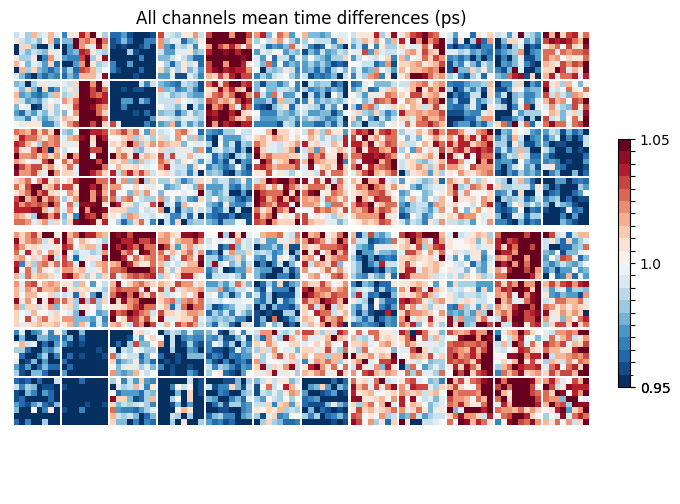

In [8]:
# Custom base values heatmap

heatmapR = np.zeros((32, 96))
heatmapL = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    #heatmapR[index] = highinteventcounts[i]
    #heatmapR[index] = lowinteventcounts[i]
    #heatmapR[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    #heatmapR[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapR[index] = heatmapRhigh[index]
    #heatmapR[index] = heatmapRlow[index]
    #heatmapR[index] = highinteventcounts[i] / 5.4338 / lowinteventcounts[i] if lowinteventcounts[i] != 0 else -1
    #heatmapR[index] = highintppbounds[i][0] / lowintppbounds[i][0]
    #heatmapR[index] = highintoffsets[i]
    #heatmapR[index] = lowintoffsets[i]
    #heatmapR[index] = highintoffsets[i] - lowintoffsets[i]
    #heatmapR[index] = eventc[i]
    #heatmapR[index] = peak_times[i]
    #heatmapR[index] = countsmnormrel[i]
    #heatmapR[index] = offsets[i]
    #heatmapR[index] = meansnocal[i]
    #heatmapR[index] = meanscal[i]
    heatmapR[index] = normfactors[i]
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    #heatmapL[index] = highinteventcounts[i]
    #heatmapL[index] = lowinteventcounts[i]
    #heatmapL[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    #heatmapL[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapL[index] = heatmapLhigh[index]
    #heatmapL[index] = heatmapLlow[index]
    #heatmapL[index] = highinteventcounts[i] / 5.4338 / lowinteventcounts[i] if lowinteventcounts[i] != 0 else -1
    #heatmapL[index] = highintppbounds[i][0] / lowintppbounds[i][0]
    #heatmapL[index] = highintoffsets[i]
    #heatmapL[index] = lowintoffsets[i]
    #heatmapL[index] = highintoffsets[i] - lowintoffsets[i]
    #heatmapL[index] = eventc[i]
    #heatmapL[index] = peak_times[i]
    #heatmapL[index] = countsmnormrel[i]
    #heatmapL[index] = offsets[i]
    #heatmapL[index] = meansnocal[i]
    #heatmapL[index] = meanscal[i]
    heatmapL[index] = normfactors[i]
#Dead cells
for i in range(32):
   for j in range(96):
        if heatmapR[i, j] < -2000:
            heatmapR[i, j] = -1
        if heatmapL[i, j] < -2000:
            heatmapL[i, j] = -1

face_dim = 3.2
space = 1.2
blank_color = 'black'
cmap = plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
    
fig, ax = plt.subplots(figsize = (8, 6))

#rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
#ax.add_patch(rect)

# Plot R
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        if heatmapR[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Plot L
for z in range(32):
    zspace = z // 8 * space 
    for y in range(96):
        yspace = y // 8 * space
        if heatmapL[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Discrete colorbar
#cmap = plt.get_cmap('RdBu')
#bounds = np.linspace(heatmapmin, heatmapmax, 11)
#norm = colors.BoundaryNorm(bounds, cmap.N)
#mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
#diff = heatmapmax - heatmapmin
#cbar.set_ticks([heatmapmin, heatmapmin+diff*0.1, heatmapmin+diff*0.2, heatmapmin+diff*0.3, heatmapmin+diff*0.4, heatmapmin+diff*0.5, heatmapmin+diff*0.6, heatmapmin+diff*0.7, heatmapmin+diff*0.8, heatmapmin+diff*0.9, heatmapmax])
#cbar.set_ticklabels(['', round(heatmapmin, 1), '', round(heatmapmin+diff*0.25, 1), '', round(heatmapmin+diff*0.5, 1), '', round(heatmapmin+diff*0.75, 1), '', round(heatmapmax, 1), ''])

bounds = np.linspace(heatmapmin, heatmapmax, 21)
norm = colors.BoundaryNorm(bounds, cmap.N)
mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
diff = heatmapmax - heatmapmin
cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
cbar.set_ticklabels([
    '',
    #f'{heatmapmin:.2e}',
    f'{heatmapmin}',
    '', '', '', '', '', '', '', '',
    f'{heatmapmin+diff*0.5}',
    '', '', '', '', '', '', '', '', '',
    f'{heatmapmax}'
])


plt.xlim(-2,322.4)
pady = 36
plt.ylim(-104.8 - pady, 113.2)
plt.axis('off')
#plt.tight_layout()
plt.title('All channels mean time differences (ps)')
#plt.savefig(os.path.join(r'/home/kale-chen/Documents/PET/TimeCalibration/ForPaperTimeAlignment', f'meantimedifferences.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()


(array([  11.,    0.,    0.,   23.,  499., 1669., 1443., 1851.,  606.,
          42.]),
 array([-2487.43725586, -2070.01489258, -1652.5925293 , -1235.17016602,
         -817.74780273,  -400.32543945,    17.09692383,   434.51928711,
          851.94165039,  1269.36401367,  1686.78637695]),
 <BarContainer object of 10 artists>)

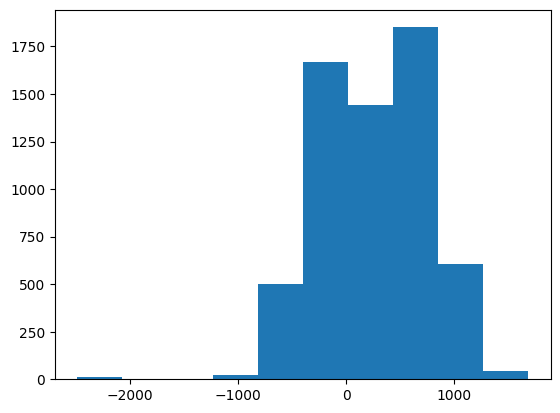

In [24]:
plt.hist(meansnocal)

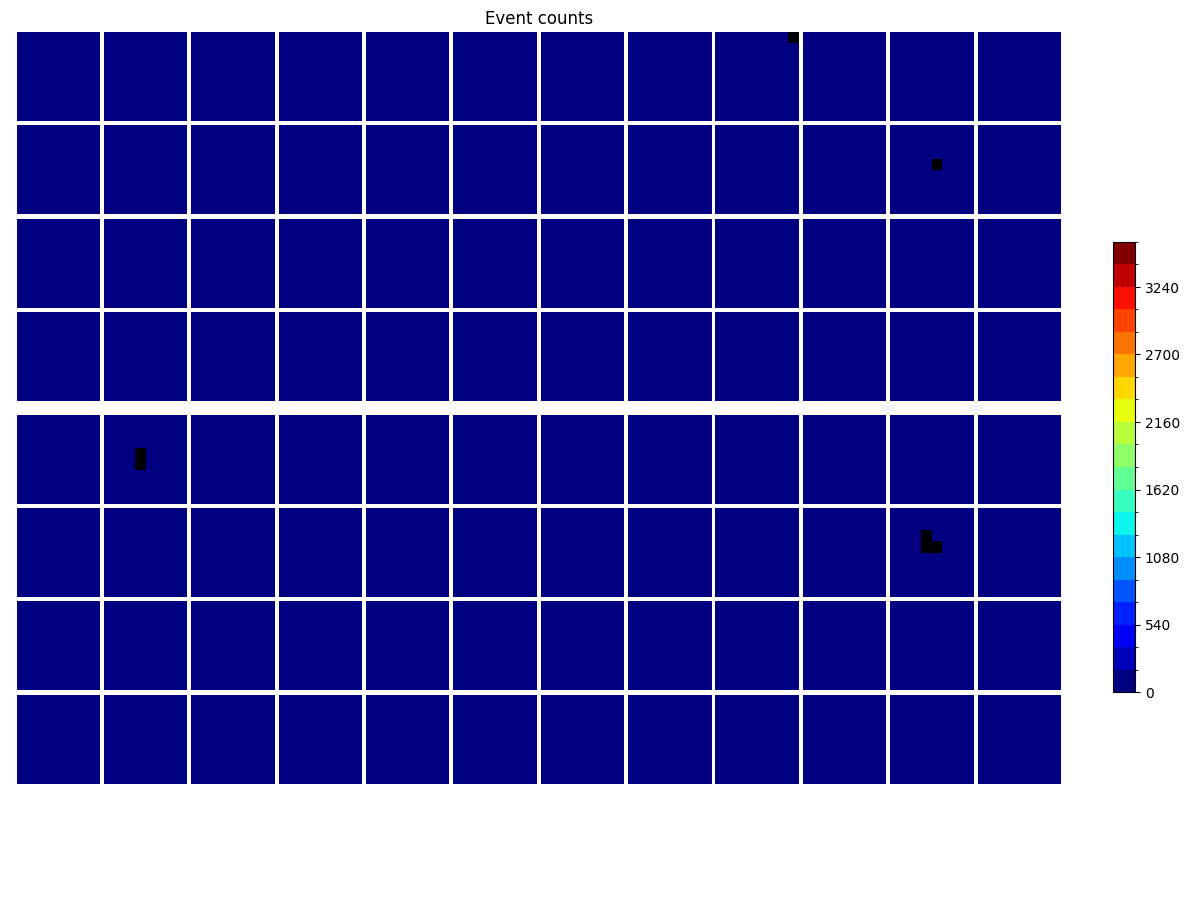

In [53]:
# Custom base values heatmap non discrete

heatmapR = np.zeros((32, 96))
heatmapL = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    #heatmapR[index] = peak_times[i]
    heatmapR[index] = counts[i]
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    #heatmapL[index] = peak_times[i]
    heatmapL[index] = counts[i]
#Dead cells
for i in range(32):
   for j in range(96):
        if heatmapR[i, j] <= 0:
            heatmapR[i, j] = -1
        if heatmapL[i, j] <= 0:
            heatmapL[i, j] = -1

face_dim = 3.2
space = 1.2
blank_color = 'black'
cmap = plt.get_cmap('jet') # 'seismic' or 'RdBu' or 'rwb'
    
fig, ax = plt.subplots(figsize = (12, 9))

#rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
#ax.add_patch(rect)

# Plot R
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        if heatmapR[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolornondiscrete(heatmapR[z, y], cmap = cmap))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Plot L
for z in range(32):
    zspace = z // 8 * space 
    for y in range(96):
        yspace = y // 8 * space
        if heatmapL[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolornondiscrete(heatmapL[z, y], cmap = cmap))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Regular colorbar
mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)

plt.xlim(-2,322.4)
pady = 32
plt.ylim(-104.8 - pady, 113.2)
plt.axis('off')
plt.tight_layout()
plt.title('Event counts')
plt.show()
